In [1]:
using Plots, Distributions,Statistics 
using MCPhyloTree
using DataFrames, DelimitedFiles
using CSV 
using Distances
using Random
using StatsBase
using StatsPlots

In [2]:
include("modelVE.jl")
include("ABC_newmodel.jl")
include("prove_dev.jl")
include("population_model_modif.jl")
include("ABCmethod.jl")
include("cellSimulation.jl")

tree_simulation (generic function with 1 method)

# Van Egeren et al. model

In [3]:
#parameters 
s=0.3 #fitenss
T=14.0 #age of onset
N=10^5 #cell population size
k=15 #number of mutated cells in data phylogenetic tree
L=53.0 #age of the patient
g=round(Int, L-T)
l=19 #average SNVs accumulation rate

19

In [4]:
#simulation
a=nothing
while a==nothing 
    global a = sim_LTT(g, N, s, k, round(Int, L), l)
end
LTT=a[1]
CF=a[2]

0.29411

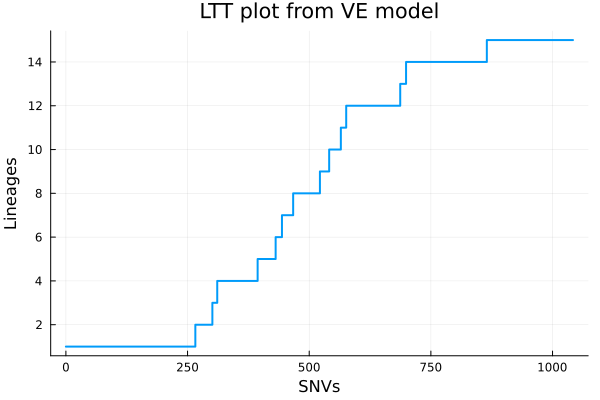

In [5]:
plot(LTT[1],LTT[2],title="LTT plot from VE model", xlabel="SNVs", ylabel="Lineages",label=false,width=2)

In [ ]:
#CSV.write("LTTVE.csv", DataFrame(Mutations=LTT[1], Linages=LTT[2]))

"LTTVE.csv"

# Williams et al. model

In [6]:
#parameters 
N=10^5 #cell population size
T_m=14.6 #age of onset
s_y=0.4 #fitness of the mutated cells
s = log(1+s_y) 
k=15 #number of mutated cells in data phylogenetic tree
L=53.2 #age of the patient
l=19.0 #average SNVs accumulation rate

19.0

In [7]:
#run simulation
S_result = run_selection_sim(N, T_m, L, s)
                
if S_result !== nothing
    #construct tree
    tree = construct_mutated_tree(S_result, k, l)
    #construct LTT plot
    LTT = LTT_plot(tree, l, L, 0.0)
    CF=S_result.CF
end

0.9217992458251032

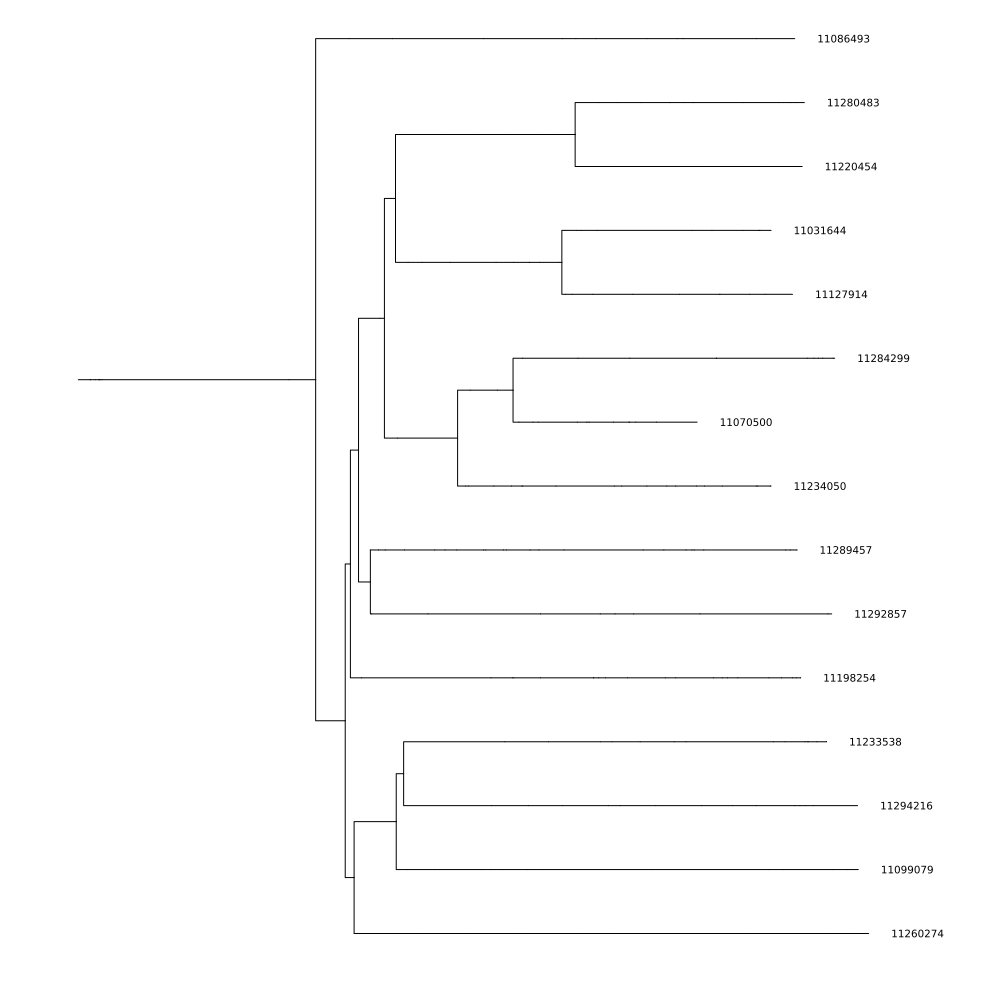

In [8]:
plot(tree)

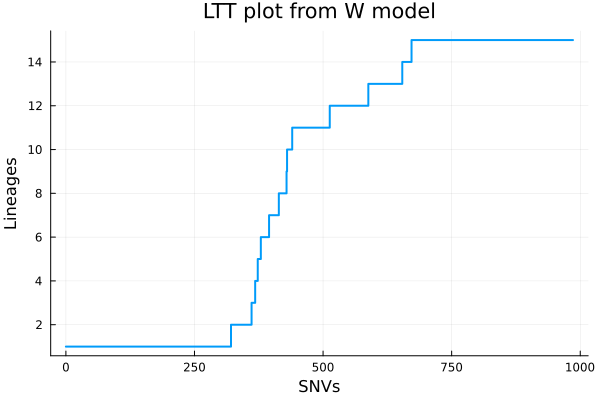

In [9]:
plot(LTT[1],LTT[2],title="LTT plot from W model", xlabel="SNVs", ylabel="Lineages",label=false,width=2)

In [ ]:
#CSV.write("LTTW.csv", DataFrame(Mutations=LTT[1], Linages=LTT[2]))

"LTTW.csv"

# Hermange et al. and exact phylogenetic tree

In [27]:
#parameters
N=10^5 #cell population size
T_m=14.6 #age of onset
p2=0.04
p0=0.01
k=15 #number of mutated cells in data phylogenetic tree
L=53.2 #age of the patient
l=19.0 #
N_threshold=2000
α=1/30

0.03333333333333333

In [28]:
#simulation
p=Parameters(α,p0,p2,T_m*365)
h=run_simulation(p, L*365,0,N_threshold);

In [29]:
#tree construction
n=collect(values(h.nodes))
root=n[findfirst(x -> x.parent === nothing,n)]
nw_string=to_newick_with_node_age(root)
tree=parsenewick(nw_string)

RootedTree with 2001 tips and 1 root. Leaf names are 64629, 65651, 65846, 65847, 62108, ... [1995 omitted] ... and 65518

58139 nodes: [RecursiveNode{OneRoot} '64629', a leaf with an incoming connection (branch 1), RecursiveNode{OneRoot} '64279', an internal node with 1 inbound and 1 outbound connection (branches 2 and 1), RecursiveNode{OneRoot} '61130', an internal node with 1 inbound and 1 outbound connection (branches 3 and 2), RecursiveNode{OneRoot} '61075', an internal node with 1 inbound and 1 outbound connection (branches 4 and 3), RecursiveNode{OneRoot} '61050', an internal node with 1 inbound and 1 outbound connection (branches 5 and 4) ... 58133 missing ... RecursiveNode{OneRoot} '1', a root node with 1 outbound connection (branch 58138)]

58138 branches: [RecursiveBranch{OneRoot} 1, from node '64279' to node '64629' (length 5.506349307515848), RecursiveBranch{OneRoot} 2, from node '61130' to node '64279' (length 50.14521129682362), RecursiveBranch{OneRoot} 3, from node '6107

In [30]:
#sample of k cells 
t=subsample_mutated_tree(h,tree,k)

RootedTree with 15 tips and 1 root. Leaf names are 63573, 64956, 64432, 63827, 66186, ... [9 omitted] ... and 63959

2341 nodes: [RecursiveNode{OneRoot} '63573', a leaf with an incoming connection (branch 3898), RecursiveNode{OneRoot} '62934', an internal node with 1 inbound and 1 outbound connection (branches 3899 and 3898), RecursiveNode{OneRoot} '61969', an internal node with 1 inbound and 1 outbound connection (branches 3900 and 3899), RecursiveNode{OneRoot} '61543', an internal node with 1 inbound and 1 outbound connection (branches 3901 and 3900), RecursiveNode{OneRoot} '60647', an internal node with 1 inbound and 1 outbound connection (branches 3902 and 3901) ... 2335 missing ... RecursiveNode{OneRoot} '1', a root node with 1 outbound connection (branch 58138)]

2340 branches: [RecursiveBranch{OneRoot} 3898, from node '62934' to node '63573' (length 9.427302811443951), RecursiveBranch{OneRoot} 3899, from node '61969' to node '62934' (length 15.204314339496705), RecursiveBranch{O

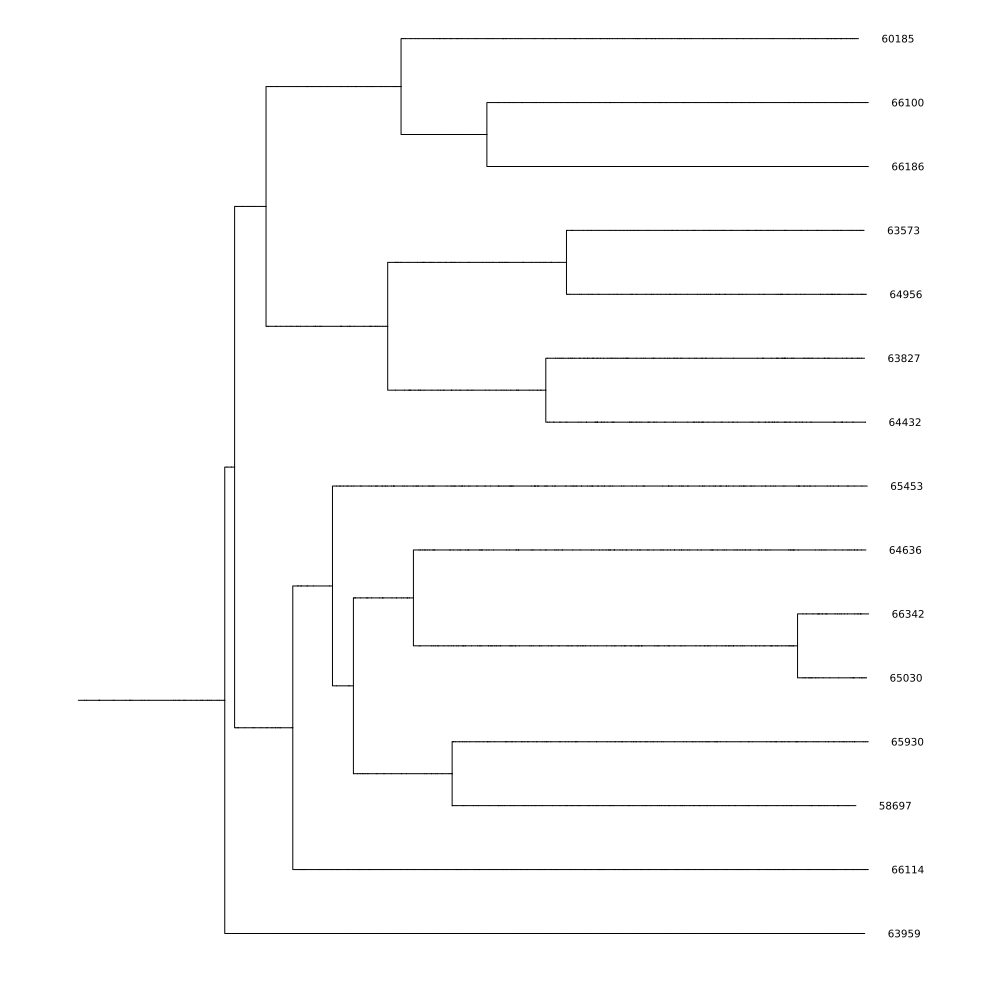

In [31]:
plot(t)

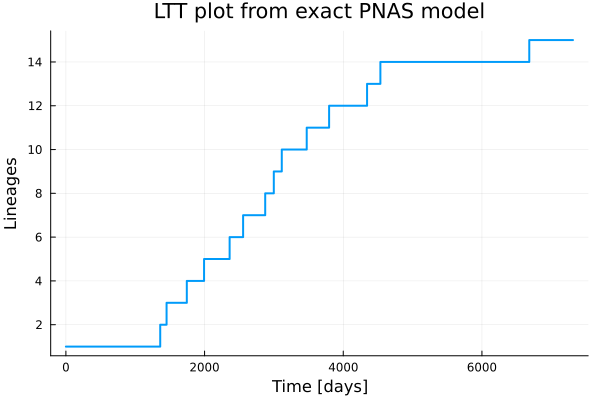

In [32]:
LTT = LTT_plot(t, 1.0, L, 0.0)
plot(LTT[1], LTT[2],title="LTT plot from exact PNAS model", xlabel="Time [days]", ylabel="Lineages",label=false,width=2)